In [194]:
import pandas as pd
import matplotlib.pyplot as plt
import os

WD =  os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(WD, "..", ".."))
RESULTS = os.path.join(BASE_DIR, "data", "results", "anti", "anti_naive.csv")

df = pd.read_csv(RESULTS)

cols = [
    "build_time_us",
    "query_time_us",
    "memory_bytes"
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["is_timeout"] = df["build_time_us"].isna()

In [195]:
clean = df[df["is_timeout"] == False].copy()

clean["build_time_us"] = clean["build_time_us"] / 1000
clean["query_time_us"] = clean["query_time_us"] / 1000
clean["memory_bytes"] = clean["memory_bytes"] / (1024 * 1024)

clean = clean.rename(columns={
    "build_time_us": "build_time_ms",
    "query_time_us": "query_time_ms",
    "memory_bytes": "memory_mib"
})

clean

,dataset,status,impl,positive_set_size,negative_set_size,number_of_queries,build_time_ms,query_time_ms,memory_mib,total_output_len,is_timeout
0,anti_naive1,OK,naive,17.0,15.0,100000.0,0.478,1883.855,0.109772,100000.0,False
1,anti_naive1,OK,precomp,17.0,15.0,100000.0,5.277,31.440,1.791016,100000.0,False
2,anti_naive1,OK,sqrt,17.0,15.0,100000.0,10.068,58.043,1.779575,100000.0,False
3,anti_naive1,OK,naive,17.0,15.0,100000.0,0.395,1725.436,0.109772,100000.0,False
4,anti_naive1,OK,precomp,17.0,15.0,100000.0,7.831,67.494,1.791016,100000.0,False
5,anti_naive1,OK,sqrt,17.0,15.0,100000.0,5.305,26.930,1.779575,100000.0,False
6,anti_naive1,OK,naive,17.0,15.0,100000.0,0.209,1459.060,0.109772,100000.0,False
7,anti_naive1,OK,precomp,17.0,15.0,100000.0,5.545,45.529,1.791016,100000.0,False
8,anti_naive1,OK,sqrt,17.0,15.0,100000.0,6.206,49.796,1.779575,100000.0,False
9,anti_naive1,OK,naive,17.0,15.0,100000.0,0.170,1535.055,0.109772,100000.0,False


In [196]:
summary = (
    clean.groupby(["dataset", "impl"])
        .agg(
            build_mean_ms=("build_time_ms", "mean"),
            build_std_ms=("build_time_ms", "std"),
            query_mean_ms=("query_time_ms", "mean"),
            query_std_ms=("query_time_ms", "std"),
            memory_mib=("memory_mib", "mean"),
            num_pos=("positive_set_size", "first"),
            num_neg=("negative_set_size", "first"),
            num_queries=("number_of_queries", "first"),
        )
        .reset_index()
)

summary["total_mean_ms"] = (
    summary["build_mean_ms"] +
    summary["query_mean_ms"]
)

summary["query_ms_per_query"] = (
    summary["query_mean_ms"] /
    summary["num_queries"]
)

summary["num_traces"] = (
    summary["num_pos"] +
    summary["num_neg"]
)


summary

,dataset,impl,build_mean_ms,build_std_ms,query_mean_ms,query_std_ms,memory_mib,num_pos,num_neg,num_queries,total_mean_ms,query_ms_per_query,num_traces
0,anti_naive1,naive,0.2826,0.144652,1651.3036,165.869207,0.109772,17.0,15.0,100000.0,1651.5862,0.016513,32.0
1,anti_naive1,precomp,5.8702,1.102285,42.7936,15.028513,1.791016,17.0,15.0,100000.0,48.6638,0.000428,32.0
2,anti_naive1,sqrt,6.4238,2.077098,40.2322,13.816727,1.779575,17.0,15.0,100000.0,46.6560,0.000402,32.0
3,anti_naive2,naive,126.2354,11.734156,21760.1054,1227.149054,72.088745,2.0,0.0,1000.0,21886.3408,21.760105,2.0
4,anti_naive2,precomp,4966.0248,440.656820,0.0546,0.006269,1065.933289,2.0,0.0,1000.0,4966.0794,0.000055,2.0
5,anti_naive2,sqrt,5038.7560,295.749596,0.0886,0.054711,1065.933292,2.0,0.0,1000.0,5038.8446,0.000089,2.0
6,anti_naive3,naive,6.9332,0.990043,51927.4594,1809.151957,4.219208,2.0,0.0,50000.0,51934.3926,1.038549,2.0
7,anti_naive3,precomp,298.5424,56.977836,2.3178,0.166648,59.069534,2.0,0.0,50000.0,300.8602,0.000046,2.0
8,anti_naive3,sqrt,294.9924,90.153918,3.0384,1.643936,59.069538,2.0,0.0,50000.0,298.0308,0.000061,2.0
9,anti_naive4,precomp,806.7002,215.007943,7.2772,4.614708,152.220772,102.0,100.0,100000.0,813.9774,0.000073,202.0


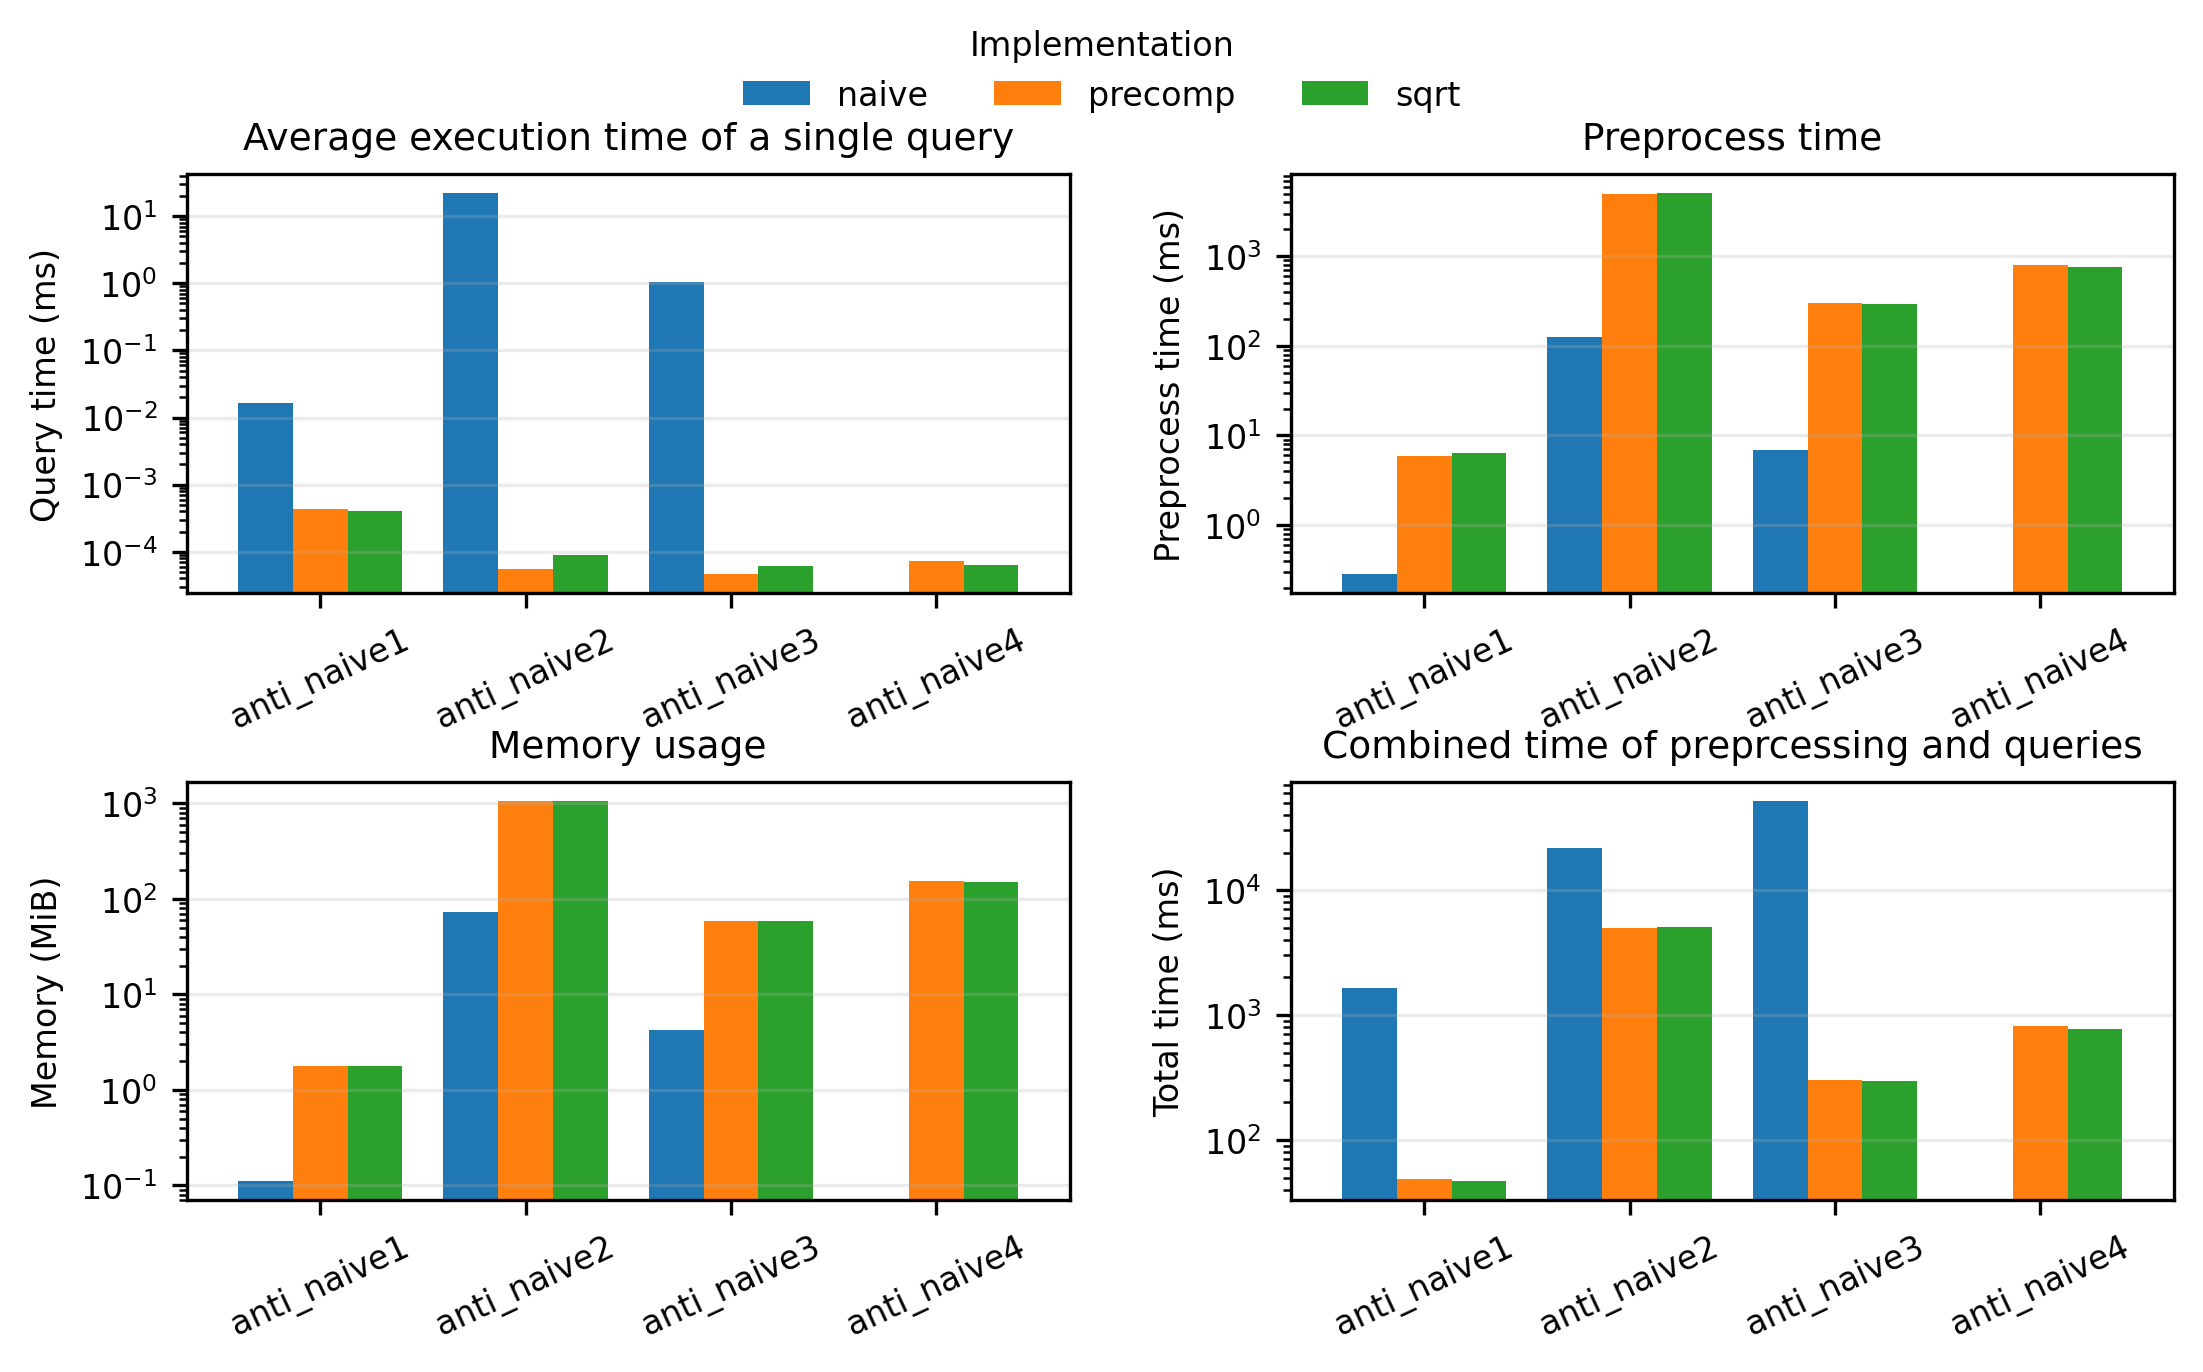

In [197]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.5), dpi=300)

metrics = [
    ("query_ms_per_query", "Query time (ms)", "Average execution time of a single query", True),
    ("build_mean_ms", "Preprocess time (ms)", "Preprocess time", True),
    ("memory_mib", "Memory (MiB)", "Memory usage", True),
    ("total_mean_ms", "Total time (ms)", "Combined time of preprcessing and queries", True),
]

for ax, (metric, ylabel, title, use_log) in zip(axes.flat, metrics):
    pivot = summary[:25].pivot(
        index="dataset",
        columns="impl",
        values=metric
    )

    pivot.plot(
        kind="bar",
        ax=ax,
        width=0.8
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

    if use_log:
        ax.set_yscale("log")

    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.25)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Implementation",
    loc="upper center",
    ncol=min(len(labels), 4),
    frameon=False,
)

for ax in axes.flat:
    ax.legend().remove()

plt.subplots_adjust(
    left=0.07,
    right=0.99,
    bottom=0.12,
    top=0.88,
    wspace=0.25,
    hspace=0.45
)

plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_17396\1519369374.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


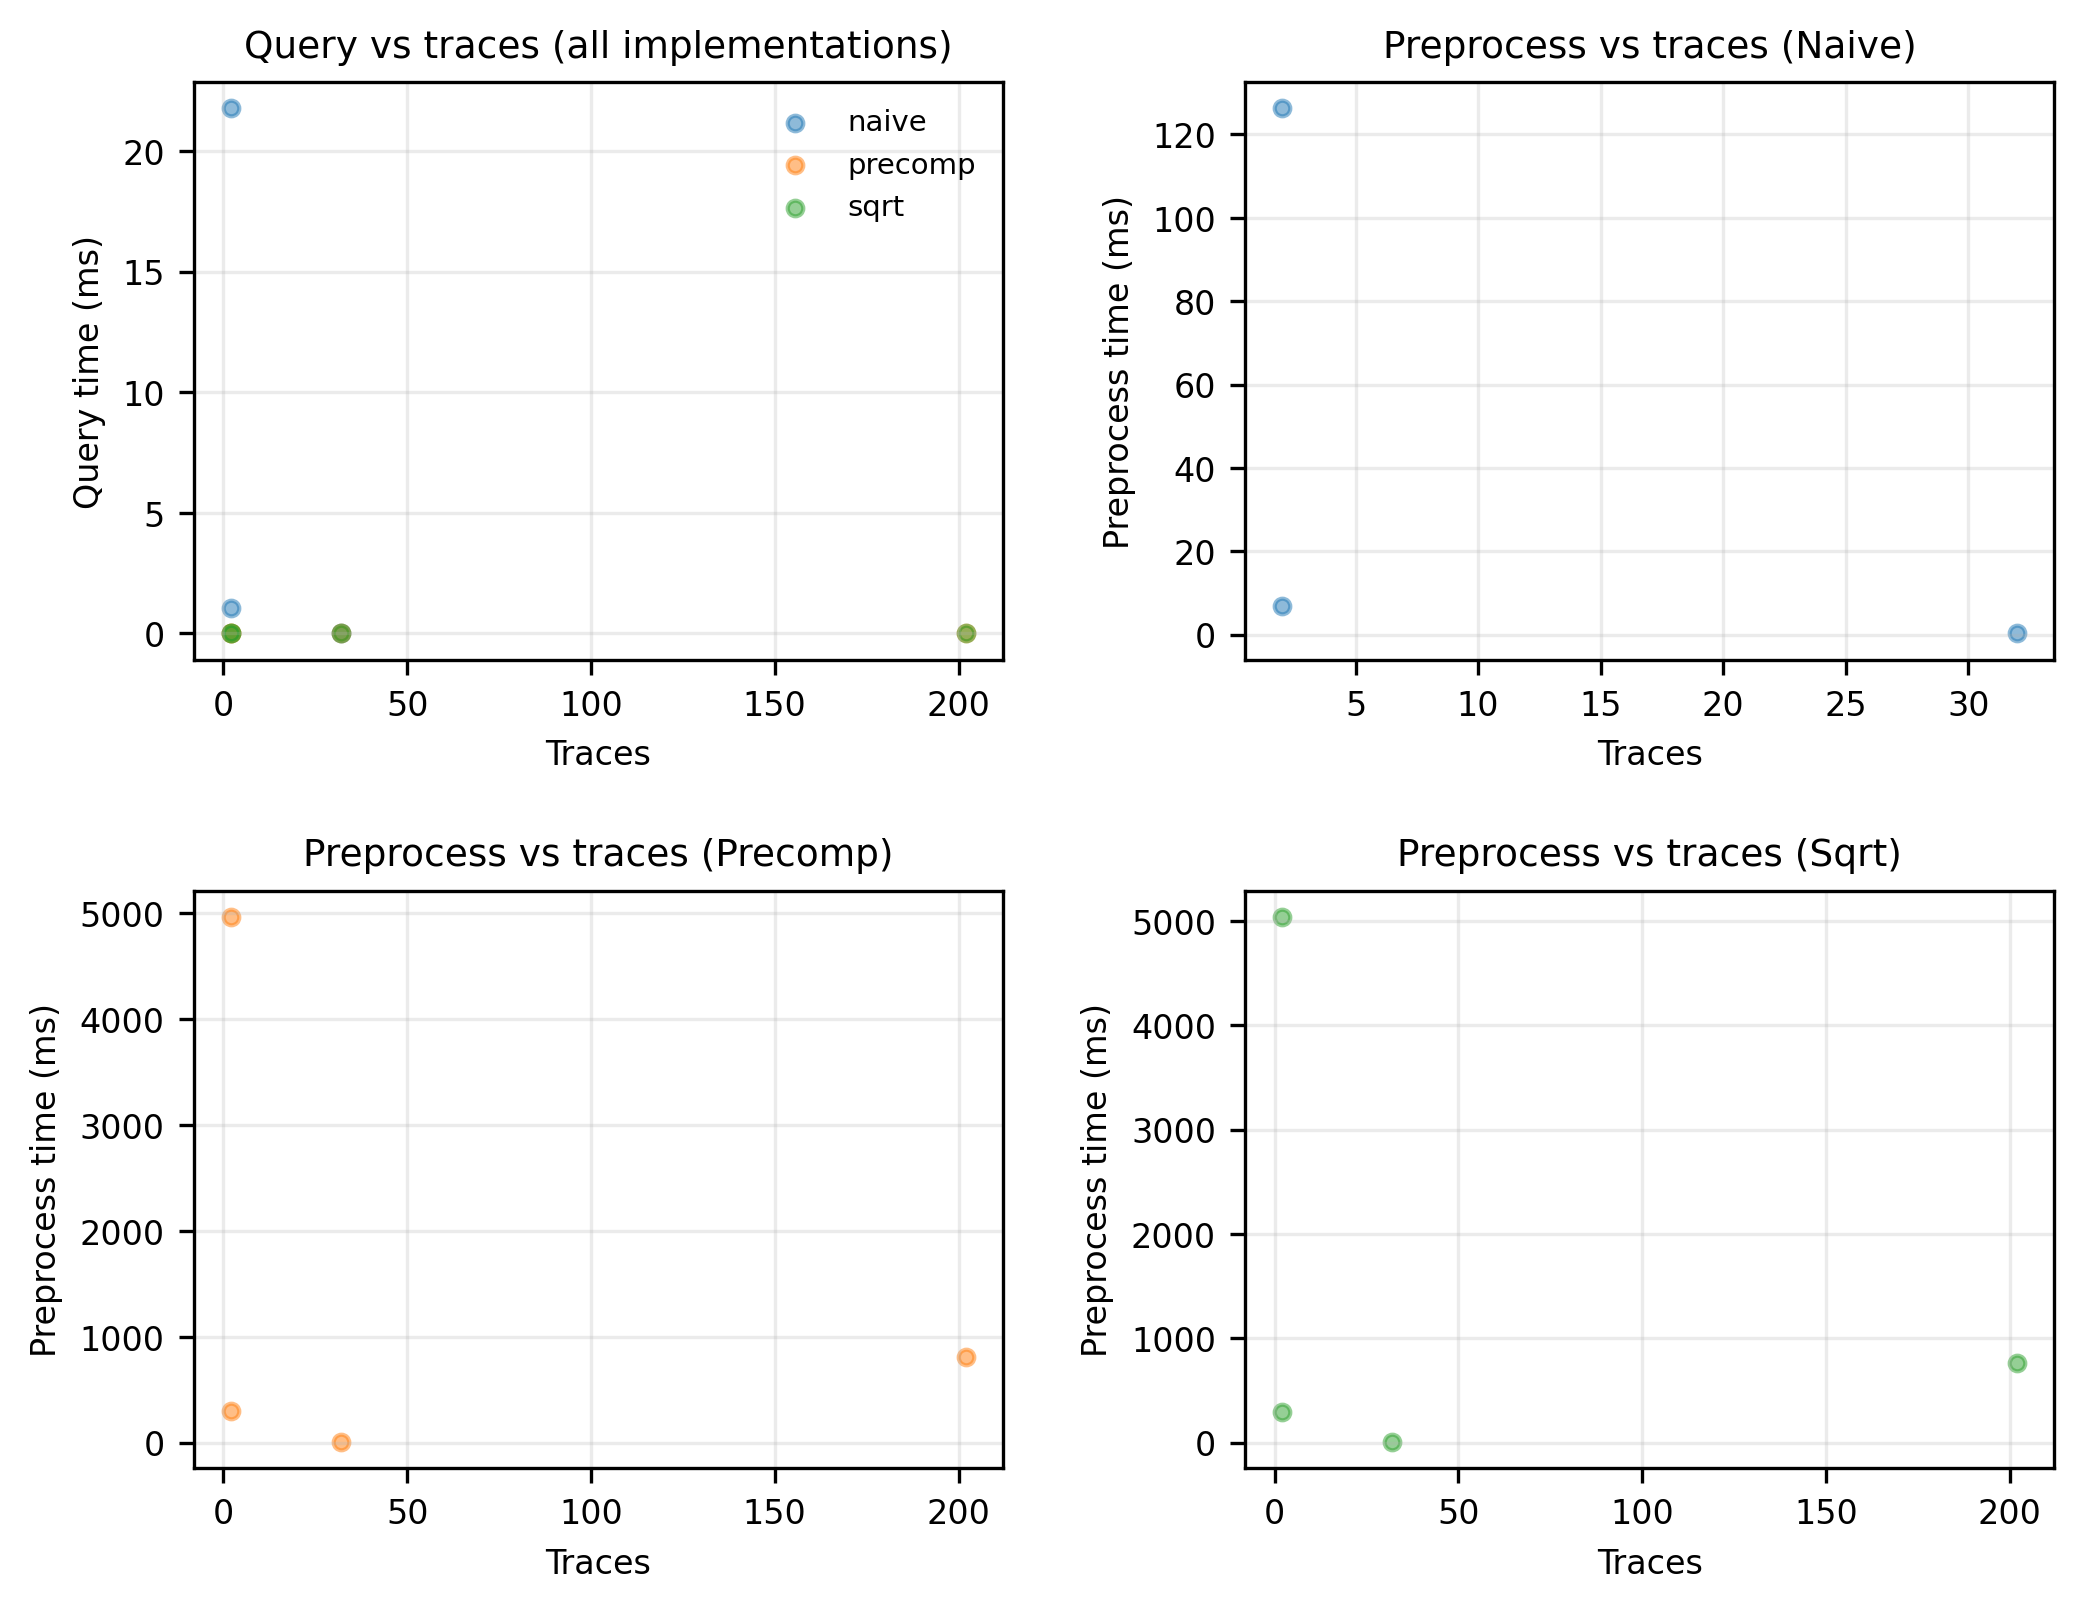

In [198]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

colors = {
    "naive": "tab:blue",
    "precomp": "tab:orange",
    "sqrt": "tab:green"
}


from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(8, 6), dpi=300)


gs = GridSpec(2, 2, figure=fig, wspace=0.3, hspace=0.4)


ax00 = fig.add_subplot(gs[0, 0])

for impl in ["naive", "precomp", "sqrt"]:
    sub = summary[summary["impl"] == impl].sort_values("num_traces")
    ax00.scatter(
        sub["num_traces"],
        sub["query_ms_per_query"],
        s=14,
        alpha=0.5,
        color=colors[impl],
        label=impl
    )

ax00.set_title("Query vs traces (all implementations)")
ax00.set_xlabel("Traces")
ax00.set_ylabel("Query time (ms)")
ax00.grid(alpha=0.25)
ax00.legend(frameon=False, fontsize=7)


ax01 = fig.add_subplot(gs[0, 1])

sub = summary[summary["impl"] == "naive"].sort_values("num_traces")
ax01.scatter(sub["num_traces"], sub["build_mean_ms"], s=14, alpha=0.5, color=colors["naive"])

ax01.set_title("Preprocess vs traces (Naive)")
ax01.set_xlabel("Traces")
ax01.set_ylabel("Preprocess time (ms)")
ax01.grid(alpha=0.25)

ax10 = fig.add_subplot(gs[1, 0])

sub = summary[summary["impl"] == "precomp"].sort_values("num_traces")
ax10.scatter(sub["num_traces"], sub["build_mean_ms"], s=14, alpha=0.5, color=colors["precomp"])

ax10.set_title("Preprocess vs traces (Precomp)")
ax10.set_xlabel("Traces")
ax10.set_ylabel("Preprocess time (ms)")
ax10.grid(alpha=0.25)

ax11 = fig.add_subplot(gs[1, 1])

sub = summary[summary["impl"] == "sqrt"].sort_values("num_traces")
ax11.scatter(sub["num_traces"], sub["build_mean_ms"], s=14, alpha=0.5, color=colors["sqrt"])

ax11.set_title("Preprocess vs traces (Sqrt)")
ax11.set_xlabel("Traces")
ax11.set_ylabel("Preprocess time (ms)")
ax11.grid(alpha=0.25)

plt.tight_layout()
plt.show()

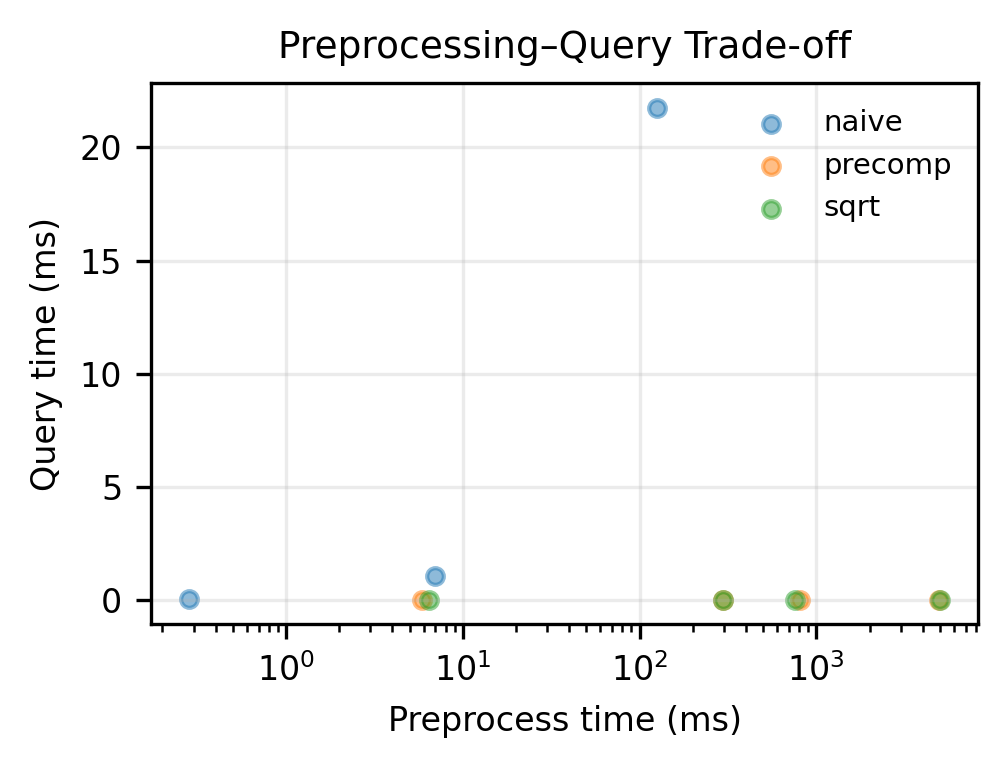

In [199]:
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
})

fig, ax = plt.subplots(figsize=(3.4, 2.6), dpi=300)

impls = summary["impl"].unique()

for impl in impls:
    sub = summary[summary["impl"] == impl]
    ax.scatter(
        sub["build_mean_ms"],
        sub["query_ms_per_query"],
        s=16,
        alpha=0.5,
        label=impl
    )

ax.set_title("Preprocessing–Query Trade-off")
ax.set_xlabel("Preprocess time (ms)")
ax.set_ylabel("Query time (ms)")
ax.set_xscale("log")
ax.grid(alpha=0.25)

ax.legend(frameon=False, fontsize=7)

plt.tight_layout()
plt.show()